## > run

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics.cluster import adjusted_rand_score

## > run
Essas são as variáveis usadas para percorrer os timestamps:

- **minpts_max**: irá percorer de 2 até minpts -1, step 2 
- **local**: a pasta onde será salvo os resultados, é também o nome do dataset
- **ti**: imestamp inicial
- **tf**: timestamp final (acrescentar +1 por conta do FOR)

In [2]:
minpts_max = 201
local      = "kddcup"
ti         = 200
tf         = 1801
skip       = []

## > run
Gera o arquivo ARI_partitions que é o valor de ARI da comparação das partições do CoreStream com o HDBSCAN e o Hastream com o HDBSCAN para cada minpts.

In [3]:
for t in range(ti, tf, ti):
    try:
        df_partition_hastream = pd.read_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/all_partitions_mcs.csv", sep=',')
        df_partition_hastream.index = [x for x in range(2, minpts_max, 2)]

        df_partition_hdbscan = pd.read_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/all_partitions_hdbscan.csv", sep=',')
        df_partition_hdbscan.index = [x for x in range(2, minpts_max, 2)]

        # Prepare the df_heatmap
        data = {}

        for i in range(2, minpts_max):
            data[i] = [0.0 for x in range((minpts_max - 1) // 2)]

        df_heatmap = pd.DataFrame(data, index=[x for x in range(2, minpts_max, 2)], columns=[x for x in range(2, minpts_max, 2)])
        df_ARI     = pd.DataFrame([0.0 for x in range(2, minpts_max, 2)], index=[x for x in range(2, minpts_max, 2)], columns=["ARI"])
        
        # ARI
        for i in range(2, minpts_max, 2):
            for j in range(2, minpts_max, 2):
                ARI = adjusted_rand_score(df_partition_hastream.loc[i], df_partition_hdbscan.loc[j])

                df_heatmap.at[i, j] = ARI
                
                if i == j:
                    df_ARI.at[i, 'ARI'] = ARI

        df_heatmap.to_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/heatmap.csv", encoding='utf-8')
        df_ARI.to_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.csv", encoding='utf-8')
        
        # PLot Heatmap
    #    sns.set(rc={"figure.figsize":(16, 14)})
    #    sns.heatmap(df_heatmap)

    #    plt.title("Heatmap TIMESTAMP " + str(t) + " | # Points: " + str(df_partition_hastream.shape[1]) + " | Mean: " + str(round(df_heatmap.values.mean(), 4)) + " | std: " + str(round(df_heatmap.values.std(), 4)), fontsize=24)
    #    plt.xlabel("HDBSCAN partitions", fontsize=26)
    #    plt.ylabel("HAStream partitions", fontsize=26)
    #    plt.savefig("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/heatmap.png")
    #    plt.close()

        # Plot ARI
        plt.figure(figsize=(30, 15))
        plt.title("ARI Offline time " + str(t) + " | # Points: " + str(df_partition_hastream.shape[1]) + " | Mean: " + str(round(df_heatmap.values.mean(), 4)) + " | std: " + str(round(df_heatmap.values.std(), 4)), fontsize=24)
        plt.xlabel("MinPts Partition", fontsize=26)
        plt.ylabel("ARI", fontsize=26)
        plt.bar([x for x in range(2, minpts_max, 2)], df_ARI['ARI'], label='ARI Partition', color="blue")
        plt.savefig("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.png")
        plt.close()

        #data = {}

        #for i in range(4):
        #    data[i] = [0.0 for x in range((minpts - 1) // 2)]

        #df_max = pd.DataFrame(data, index=[x for x in range(2, minpts, 2)])
        #df_max.columns = columns=['HDBSCAN', 'Max_ARI', 'mean', 'std']

        #for i in range(1, minpts//2 + 1):

        #    ari_max = 0.0

        #    df_max.at[i * 2, 'mean'] = df_heatmap.loc[i * 2].mean()
        #    df_max.at[i * 2, 'std']  = df_heatmap.loc[i * 2].std()

        #    for j in range(1, minpts//2 + 1):
        #        if(df_heatmap.loc[i * 2][j * 2] > ari_max):
        #            ari_max = df_heatmap.loc[i * 2][j * 2]
        #            df_max.at[i * 2, 'HDBSCAN'] = j * 2
        #            df_max.at[i * 2, 'Max_ARI'] = ari_max

        #plt.figure(figsize=(18, 8))
        #plt.title("Max ARI", fontsize=26)
        #plt.xlabel("MinPts HAStream", fontsize=24)
        #plt.ylabel("ARI", fontsize=24)
        #plt.plot(df_max.index, df_max['Max_ARI'], marker='o', mec='r', mfc='r', color='b')
        #plt.savefig("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/max_ari.png")
        #plt.close()

        #df_max.to_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/max_value.csv", encoding='utf-8')

        print(t)
    except FileNotFoundError:
        print(f"Erro: O arquivo não foi encontrado.")

200
400
600
800
1000
1200
1400
1600
1800


In [4]:
df_mean_std_hastream = pd.DataFrame(index=[x for x in range(2, 201, 2)], columns=range(1, 5))

for t in range(ti, tf, ti):
    try:
        df_max_ari_hastream = pd.read_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.csv", sep=',', index_col=0)

        df_mean_std_hastream[t / ti] = df_max_ari_hastream['ARI']

        print(t)
        
    except FileNotFoundError:
        print(f"Erro: O arquivo não foi encontrado.")

200
400
600
800
1000
1200
1400
1600
1800


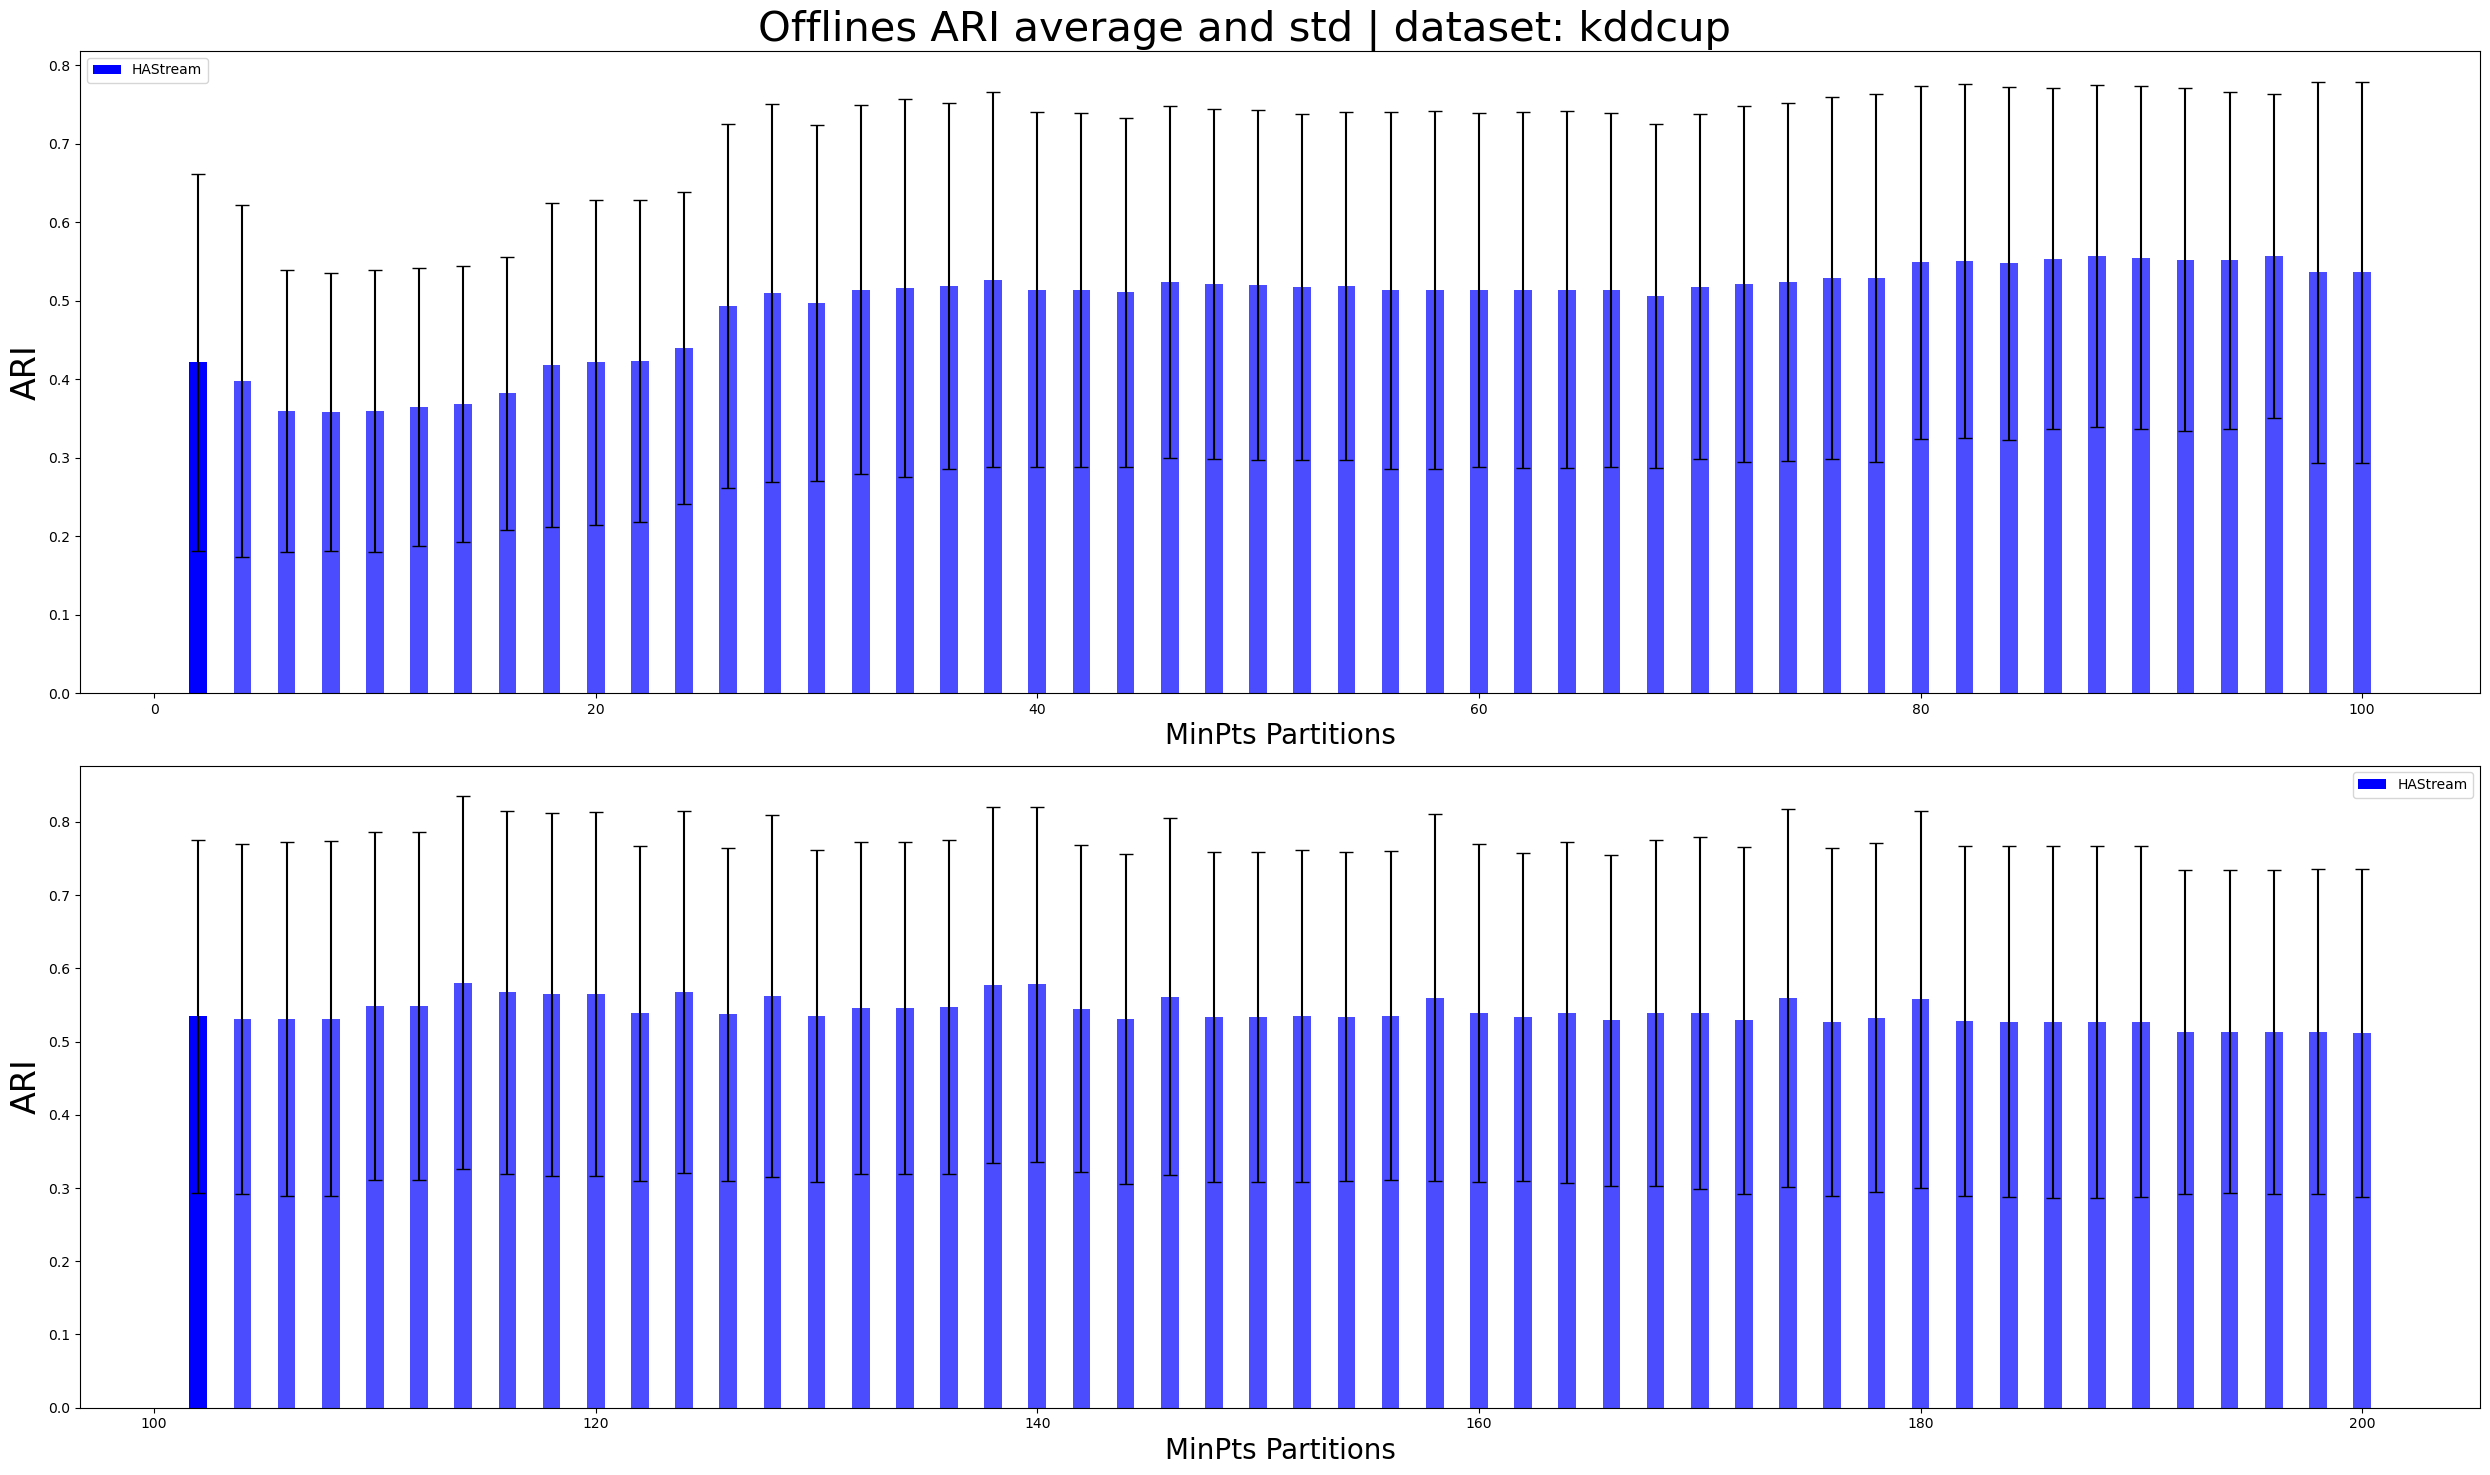

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(25, 15))

fig.suptitle('Offlines ARI average and std' + " | dataset: " + str(local), fontsize=30)

axs[0].bar(2, df_mean_std_hastream.mean(axis=1)[2], label='HAStream', color="blue")
axs[0].set_xlabel("MinPts Partitions", fontsize=20)
axs[0].set_ylabel("ARI", fontsize=24)
    
for minpts in range(2, 101, 2):
    axs[0].bar(minpts, df_mean_std_hastream.mean(axis=1)[minpts], yerr=df_mean_std_hastream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="blue")
    
axs[0].legend()

axs[1].bar(102, df_mean_std_hastream.mean(axis=1)[102], label='HAStream', color="blue")
axs[1].set_xlabel("MinPts Partitions", fontsize=20)
axs[1].set_ylabel("ARI", fontsize=24)

for minpts in range(102, 201, 2):
    axs[1].bar(minpts, df_mean_std_hastream.mean(axis=1)[minpts], yerr=df_mean_std_hastream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="blue")

axs[1].legend()

plt.tight_layout()
plt.show()

fig.savefig("results/" + local + "/flat_solutions/ari_mean_std_resume.png")

#plt.close()

fig, axs = plt.subplots(2, 1, figsize=(25, 15))

fig.suptitle('timestamps ARI average and std' + " | dataset: " + str(local), fontsize=30)

axs.bar(2, df_mean_std_hastream.mean(axis=1)[2], label='HAStream', color="blue")
axs.set_xlabel("MinPts Partitions", fontsize=20)
axs.set_ylabel("ARI", fontsize=24)
    
for minpts in range(2, 101, 2):
    axs.bar(minpts, df_mean_std_hastream.mean(axis=1)[minpts], yerr=df_mean_std_hastream.std(axis=1)[minpts], capsize=5, align='center', alpha=0.7, ecolor='black', color="blue")
    
axs.legend()

plt.tight_layout()
plt.show()

fig.savefig("results/" + local + "/flat_solutions/ari_mean_std_resume.png")

#plt.close()

plt.figure(figsize=(35, 15))
plt.title("ARI Timestamps Dataset " + str(local), fontsize=26)
plt.xlabel("MinPts HAStream", fontsize=24)
plt.ylabel("ARI", fontsize=24)

color = ['r', 'g', 'b', 'orange']

for t in range(ti, tf, ti):
    df_ARI = pd.read_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.csv", sep=',', index_col=0)
    
    partitions = []
    start      = 1.25 + (((t - ti) / ti) * 0.5)
    
    for i in range(0, 100):
        partitions.append(start + (2 * i))
    
    plt.bar(partitions, df_ARI['ARI'], label="timestamp " + str(t), color=color[((t // ti) - 1) % 4])
    plt.plot(partitions, df_ARI['ARI'], marker='o', mec=color[((t // ti) - 1) % 4], mfc=color[((t // ti) - 1) % 4], color='black')

plt.legend()
plt.savefig("results/" + local + "/flat_solutions/ari_all_timestamps.png")
plt.close()

### HEATMAP ARI

plt.figure(figsize=(18, 8))
plt.title("Max ARI Timestamps Dataset " + str(local), fontsize=26)
plt.xlabel("MinPts HAStream", fontsize=24)
plt.ylabel("ARI", fontsize=24)

color = ['r', 'g', 'b', 'orange']

for t in range(ti, tf, ti):
    df_max = pd.read_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/max_value.csv", sep=',', index_col=0)

    plt.plot(df_max.index, df_max['Max_ARI'], marker='o', mec=color[(t // ti) - 1], mfc=color[(t // ti) - 1], color='black', label="timestamp" + str(t))

plt.legend()
plt.savefig("results/" + local + "/flat_solutions/max_ari_all_timestamps.png")
plt.close()

for t in range(ti, tf, ti):
    df_partition_hastream = pd.read_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/all_partitions_mcs.csv", sep=',')
    df_partition_hastream.index = [x for x in range(2, minpts, 2)]

    df_partition_hdbscan = pd.read_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/all_partitions_hdbscan.csv", sep=',')
    df_partition_hdbscan.index = [x for x in range(2, minpts, 2)]

    # Prepare the df_heatmap
    data = {}

    for i in range(2, minpts):
        data[i] = [0.0 for x in range(100)]
    
    df_heatmap = pd.DataFrame(data, index=[x for x in range(2, minpts, 2)], columns=[x for x in range(2, minpts, 2)])

    # ARI
    for i in range(2, minpts, 2):
        for j in range(2, minpts, 2):
            ARI = adjusted_rand_score(df_partition_hastream.loc[i], df_partition_hdbscan.loc[j])
    
            df_heatmap.at[i, j] = ARI
    
    df_heatmap.to_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/heatmap.csv", encoding='utf-8')

    # PLot Heatmap
    sns.set(rc={"figure.figsize":(16, 14)})
    sns.heatmap(df_heatmap)
    
    plt.title("Heatmap TIMESTAMP " + str(t) + " | # Points: " + str(df_partition_hastream.shape[1]) + " | Mean: " + str(round(df_heatmap.values.mean(), 4)) + " | std: " + str(round(df_heatmap.values.std(), 4)), fontsize=24)
    plt.xlabel("HDBSCAN partitions", fontsize=26)
    plt.ylabel("HAStream partitions", fontsize=26)
    plt.savefig("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/heatmap.png")
    plt.close()

    data = {}

    for i in range(4):
        data[i] = [0.0 for x in range(100)]
    
    df_max = pd.DataFrame(data, index=[x for x in range(2, minpts, 2)])
    df_max.columns = columns=['HDBSCAN', 'Max_ARI', 'mean', 'std']

    for i in range(1, 101):

        ari_max = 0.0

        df_max.at[i * 2, 'mean'] = df_heatmap.loc[i * 2].mean()
        df_max.at[i * 2, 'std']  = df_heatmap.loc[i * 2].std()
    
        for j in range(1, 101):
            if(df_heatmap.loc[i * 2][j * 2] > ari_max):
                ari_max = df_heatmap.loc[i * 2][j * 2]
                df_max.at[i * 2, 'HDBSCAN'] = j * 2
                df_max.at[i * 2, 'Max_ARI'] = ari_max

    plt.figure(figsize=(18, 8))
    plt.title("Max ARI", fontsize=26)
    plt.xlabel("MinPts HAStream", fontsize=24)
    plt.ylabel("ARI", fontsize=24)
    plt.plot(df_max.index, df_max['Max_ARI'], marker='o', mec='r', mfc='r', color='b')
    plt.savefig("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/max_ari.png")
    plt.close()
                                      
    df_max.to_csv("results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/max_value.csv", encoding='utf-8')

    print(t)

df_max = pd.read_csv("results/flat_solutions/flat_solution_partitions_t100/max_value.csv", sep=',', index_col=0)
df_max

df_partition_corestream = pd.read_csv("results/ds_" + str(local) + "/flat_solutions/flat_solution_partitions_t70/all_partitions_mcs.csv", sep=',')
df_partition_corestream.index = [x for x in range(2, minpts, 2)]
df_partition_corestream

df_partition_hdbscan = pd.read_csv("results/ds_" + str(local) + "/flat_solutions/flat_solution_partitions_t70/all_partitions_hdbscan.csv", sep=',')
df_partition_hdbscan.index = [x for x in range(2, minpts, 2)]
df_partition_hdbscan

c = 0

for i, val in df_partition_hdbscan.loc[194].items():
    if (val == df_partition_hdbscan.loc[196].iloc[int(i)]):
        c += 1

print(c)

data = {}

for i in range(2, minpts):
    data[i] = [0.0 for x in range(100)]

df_heatmap = pd.DataFrame(data, index=[x for x in range(2, minpts, 2)], columns=[x for x in range(2, minpts, 2)])
df_heatmap

for i in range(2, minpts, 2):
    for j in range(2, minpts, 2):
        ARI = adjusted_rand_score(df_partition_corestream.loc[i], df_partition_hdbscan.loc[j])

        df_heatmap.at[i, j] = ARI

df_heatmap

df_heatmap.to_csv("results/flat_solutions/flat_solution_partitions_t70/heatmap.csv", encoding='utf-8')

sns.set(rc={"figure.figsize":(16, 14)})
sns.heatmap(df_heatmap)

plt.title("Heatmap TIMESTAMP 70 | Mean: " + str(round(df_heatmap.values.mean(), 4)) + " | std: " + str(round(df_heatmap.values.std(), 4)), fontsize=24)
plt.xlabel("HDBSCAN partitions", fontsize=26)
plt.ylabel("HAStream partitions", fontsize=26)
plt.savefig("results/flat_solutions/flat_solution_partitions_t70/heatmap.png")

df_heatmap.values.std()

data = {}

for i in range(4):
    data[i] = [0.0 for x in range(100)]

df_max = pd.DataFrame(data, index=[x for x in range(2, minpts, 2)])
df_max.columns = columns=['hdbscan', 'Max_ARI', 'mean', 'std']
df_max

for i in range(1, 101):

    ari_max = 0.0

    df_max.at[i * 2, 'mean'] = df_heatmap.loc[i * 2].mean()
    df_max.at[i * 2, 'std']  = df_heatmap.loc[i * 2].std()

    for j in range(1, 101):
        if(df_heatmap.loc[i * 2][j * 2] > ari_max):
            ari_max = df_heatmap.loc[i * 2][j * 2]
            df_max.at[i * 2, 'hdbscan'] = j * 2
            df_max.at[i * 2, 'Max_ARI'] = ari_max
df_max

df_max['Max_ARI'].max()

df_max[df_max['Max_ARI'] == df_max['Max_ARI'].max()]

df_max[df_max['Max_ARI'] > 0.917]